# [ Computer Vision ] [ CSE445 ] [ Assignment-2 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

In [1]:
!pip install ultralytics lap motmetrics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 4.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.6 MB/s eta 0:00:00


In [2]:
import os
import glob
import json
import time
import shutil
import random

import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Inputs
partition_dir = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition"
yolo_root = partition_dir + "/yolo_rho20"
working_dir = "/kaggle/working/"

# Protocols
BEST_YAML = "yolo12s.yaml"
RHO       = 0.20
SEED      = 42
IMGSZ     = 1920 #
BATCH     = 16
CONF_EVAL = 0.001
CONF      = 0.30
IOU_NMS   = 0.45

# Tracking
TRACKER_TYPE      = "bytetrack"
TRACK_HIGH_THRESH = 0.35
TRACK_LOW_THRESH  = 0.15
NEW_TRACK_THRESH  = 0.40
TRACK_BUFFER      = 90
MATCH_THRESH      = 0.70
FUSE_SCORE        = True
GMC_METHOD        = "sparseOptFlow"
PROXIMITY_THRESH  = 0.50
APPEARANCE_THRESH = 0.25
WITH_REID         = False

# Video
VIDEO_FILENAME    = "IoTKITs.mp4"
VIDEO_SOURCE_TYPE = "ai_generated"
VIDEO_SOURCE_DESC = ("AI-generated synthetic clip: camera panning over a dark surface scattered "
                     "with IoTKITs boards (Raspberry Pi variants, Arduino Due/Zero) - same target "
                     "classes as the training dataset.")
TRIM_START_SEC    = 0
TRIM_DURATION_SEC = 20

# Tracker evaluation
GT_AVAILABLE = False
GT_PATH      = ""
GT_IOU_THRESH = 0.50
EXPECTED_OBJECT_COUNT = 10

RAW_VIDEO = working_dir + "source_raw.mp4"
CLIP_VIDEO = working_dir + "clip_trimmed.mp4"
OUT_VIDEO = working_dir + "group-k_partB_tracked.mp4"
OUT_VIDEO_H264 = working_dir + "group-k_partB_tracked_h264.mp4"
FRAME_DIR = working_dir + "frames"
TRACKS_CSV = working_dir + "tracks.csv"
TRACKS_MOT = working_dir + "tracks_mot.txt"
TRACKER_YAML = working_dir + TRACKER_TYPE + "_partB.yaml"

os.makedirs(working_dir, exist_ok=True)
os.makedirs(FRAME_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = 0
else:
    device = "cpu"

if TRIM_DURATION_SEC < 15 or TRIM_DURATION_SEC > 30:
    print("WARNING: clip should be between 15 and 30 seconds")

print("====== Configuration ======")
print("Architecture      :", BEST_YAML)
print("Label fraction rho:", RHO)
print("Seed              :", SEED)
print("Image size        :", IMGSZ)
print("Eval conf / NMS   :", CONF_EVAL, "/", IOU_NMS)
print("Track conf / NMS  :", CONF, "/", IOU_NMS)
print("Tracker           :", TRACKER_TYPE)
print("Video             :", VIDEO_FILENAME, "|", VIDEO_SOURCE_TYPE)
print("Clip duration (s) :", TRIM_DURATION_SEC)
print("GT available      :", GT_AVAILABLE)
print("Device            :", device)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
====== Configuration ======
Architecture      : yolo12s.yaml
Label fraction rho: 0.2
Seed              : 42
Image size        : 1920
Eval conf / NMS   : 0.001 / 0.45
Track conf / NMS  : 0.3 / 0.45
Tracker           : bytetrack
Video             : IoTKITs.mp4 | ai_generated
Clip duration (s) : 20
GT available      : False
Device            : 0


## Data YAML

In [3]:
import yaml

with open(yolo_root + "/data.yaml") as f:
    info = yaml.safe_load(f)

class_names = info["names"]
NC = info["nc"]

if isinstance(class_names, dict):
    new_list = []
    for key in sorted(class_names):
        new_list.append(class_names[key])
    class_names = new_list

DATA_YAML = working_dir + "data.yaml"

text = ""
text = text + "path: " + yolo_root + "\n"
text = text + "train: images/train\n"
text = text + "val: images/val\n"
text = text + "test: images/test\n"
text = text + "nc: " + str(NC) + "\n"
text = text + "names: " + json.dumps(class_names) + "\n"

with open(DATA_YAML, "w") as f:
    f.write(text)

test_images = os.listdir(yolo_root + "/images/test")

print("data.yaml :", DATA_YAML)
print("Classes   :", NC)
print("Test images:", len(test_images))

data.yaml : /kaggle/working/data.yaml
Classes   : 32
Test images: 311


## CheckPoints

In [4]:
KEYWORDS = {
    "SimCLR": "simclr",
    "BYOL":   "byol",
    "I-JEPA": "ijepa",
    "DINOv3": "dinov3",
}

all_ckpts = glob.glob("/kaggle/input/**/best.pt", recursive=True)

CKPTS = {}
for method in KEYWORDS:
    word = KEYWORDS[method]
    for path in all_ckpts:
        run_folder = path.split("/")[-3]
        if word in run_folder.lower():
            CKPTS[method] = path
            break
    if method not in CKPTS:
        print("NOT FOUND :", method, "( keyword:", word, ")")

print()
print("Located checkpoints")
for method in CKPTS:
    path = CKPTS[method]
    size_mb = os.path.getsize(path) / 1e6
    print(method, ":", path, "(", round(size_mb, 1), "MB )")


Located checkpoints
SimCLR : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-1-simclr-detect/simclr_rho20/weights/best.pt ( 19.0 MB )
BYOL : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-2-byol-detect/byol_rho20/weights/best.pt ( 19.0 MB )
I-JEPA : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-3-ijepa-detect/ijepa_rho20/weights/best.pt ( 19.0 MB )
DINOv3 : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-4-dinov3-detect/dinov3_rho20/weights/best.pt ( 19.0 MB )


## Model-test

In [5]:
ssl_results = {}

for method in CKPTS:
    ckpt = CKPTS[method]
    tag = method.lower().replace("-", "")
    print("Evaluating:", method)

    m = YOLO(ckpt)
    r = m.val(data=DATA_YAML,
              split="test",
              imgsz=640,#
              batch=BATCH,
              conf=CONF_EVAL,
              iou=0.70,#
              device=device,
              project=working_dir,
              name=tag + "_test_eval",
              exist_ok=True,
              plots=True,
              verbose=False)

    scores = {}
    scores["precision"] = float(r.box.mp)
    scores["recall"] = float(r.box.mr)
    scores["mAP50"] = float(r.box.map50)
    scores["mAP50_95"] = float(r.box.map)

    ssl_results[method] = scores
    print(method, "done")

Evaluating: SimCLR
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO12s summary (fused): 159 layers, 9,243,264 parameters, 0 gradients, 23.2 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 5.2±3.7 MB/s, size: 43.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition/yolo_rho20/labels/test... 311 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 311/311 150.7it/s 2.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition/yolo_rho20/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.3it/s 6.1s0.2s
                   all        311        325       0.76      0.765      0.816      0.741
Sp

### Chart

SSL backbone ranking on the test set (rho = 0.2 )
SSL method  precision   recall    mAP50  mAP50_95  rank  rho
    DINOv3   0.711720 0.786790 0.800287  0.743356     1  0.2
    SimCLR   0.759724 0.764839 0.816350  0.740758     2  0.2
    I-JEPA   0.734799 0.786864 0.801406  0.732594     3  0.2
      BYOL   0.692664 0.757723 0.760801  0.691760     4  0.2

Best SSL backbone : DINOv3
Checkpoint        : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-4-dinov3-detect/dinov3_rho20/weights/best.pt
Test mAP50-95     : 0.7434
Test mAP50        : 0.8003


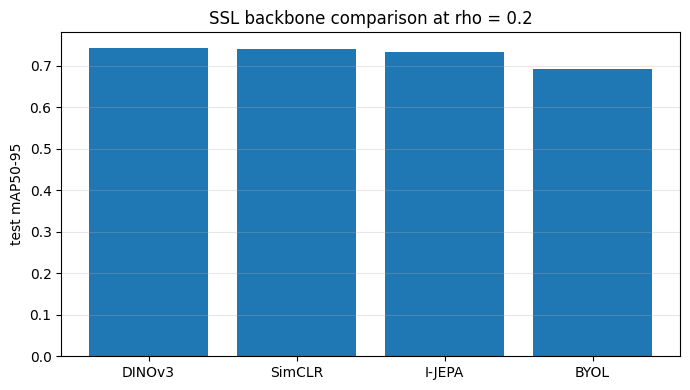

In [6]:
rank = pd.DataFrame(ssl_results).T
rank = rank.sort_values("mAP50_95", ascending=False)
rank = rank.reset_index()
rank = rank.rename(columns={"index": "SSL method"})
rank["rank"] = range(1, len(rank) + 1)
rank["rho"] = RHO

print("SSL backbone ranking on the test set (rho =", RHO,")")
print(rank.to_string(index=False))

# row 0 = best model
BEST_SSL_METHOD = rank.loc[0, "SSL method"]
BEST_CKPT = CKPTS[BEST_SSL_METHOD]
BEST_MAP5095 = rank.loc[0, "mAP50_95"]
BEST_MAP50 = rank.loc[0, "mAP50"]

rank.to_csv(working_dir + "ssl_ranking_rho20.csv", index=False)

print()
print("Best SSL backbone :", BEST_SSL_METHOD)
print("Checkpoint        :", BEST_CKPT)
print("Test mAP50-95     :", round(BEST_MAP5095, 4))
print("Test mAP50        :", round(BEST_MAP50, 4))

plt.figure(figsize=(7, 4))
plt.bar(rank["SSL method"], rank["mAP50_95"])
plt.ylabel("test mAP50-95")
plt.title("SSL backbone comparison at rho = " + str(RHO))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Winner-Export

In [7]:
export_dir = working_dir + "best_ssl_detector"
os.makedirs(export_dir, exist_ok=True)

export_ckpt = export_dir + "/" + BEST_SSL_METHOD.lower() + "_yolo12s_rho20_best.pt"
shutil.copy(BEST_CKPT, export_ckpt)

meta = {}
meta["method"] = BEST_SSL_METHOD
meta["arch"] = BEST_YAML
meta["rho"] = RHO
meta["test_mAP50"] = float(BEST_MAP50)
meta["test_mAP50_95"] = float(BEST_MAP5095)
meta["eval_conf"] = CONF_EVAL
meta["eval_iou"] = IOU_NMS
meta["seed"] = SEED

with open(export_dir + "/best_ssl_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Exported for publishing as a Kaggle dataset:")
print(" ", export_ckpt)

Exported for publishing as a Kaggle dataset:
  /kaggle/working/best_ssl_detector/dinov3_yolo12s_rho20_best.pt


## Tracking

### Load Model

In [8]:
model = YOLO(export_ckpt)
names = model.names

total_params = 0
for p in model.model.parameters():
    total_params = total_params + p.numel()

print("Detector loaded for tracking")
print("  SSL backbone  :", BEST_SSL_METHOD)
print("  architecture  :", BEST_YAML)
print("  checkpoint    :", export_ckpt)
print("  parameters    :", round(total_params / 1e6, 2), "M")
print("  classes       :", len(names))
print("  test mAP50-95 :", round(BEST_MAP5095, 4))

Detector loaded for tracking
  SSL backbone  : DINOv3
  architecture  : yolo12s.yaml
  checkpoint    : /kaggle/working/best_ssl_detector/dinov3_yolo12s_rho20_best.pt
  parameters    : 9.27 M
  classes       : 32
  test mAP50-95 : 0.7434


### Tracker yaml

In [9]:
tracker_cfg = {}
tracker_cfg["tracker_type"] = TRACKER_TYPE
tracker_cfg["track_high_thresh"] = TRACK_HIGH_THRESH
tracker_cfg["track_low_thresh"] = TRACK_LOW_THRESH
tracker_cfg["new_track_thresh"] = NEW_TRACK_THRESH
tracker_cfg["track_buffer"] = TRACK_BUFFER
tracker_cfg["match_thresh"] = MATCH_THRESH
tracker_cfg["fuse_score"] = FUSE_SCORE

if TRACKER_TYPE == "botsort":
    tracker_cfg["gmc_method"] = GMC_METHOD
    tracker_cfg["proximity_thresh"] = PROXIMITY_THRESH
    tracker_cfg["appearance_thresh"] = APPEARANCE_THRESH
    tracker_cfg["with_reid"] = WITH_REID

with open(TRACKER_YAML, "w") as f:
    for key in tracker_cfg:
        f.write(key + ": " + str(tracker_cfg[key]) + "\n")

print("Association parameters:")
for key in tracker_cfg:
    print(" ", key, ":", tracker_cfg[key])

print()
print(open(TRACKER_YAML).read())

Association parameters:
  tracker_type : bytetrack
  track_high_thresh : 0.35
  track_low_thresh : 0.15
  new_track_thresh : 0.4
  track_buffer : 90
  match_thresh : 0.7
  fuse_score : True

tracker_type: bytetrack
track_high_thresh: 0.35
track_low_thresh: 0.15
new_track_thresh: 0.4
track_buffer: 90
match_thresh: 0.7
fuse_score: True



### Video source

In [10]:
hits = glob.glob("/kaggle/input/**/" + VIDEO_FILENAME, recursive=True)

if len(hits) == 0:
    print("VIDEO NOT FOUND - attach the video dataset (upload iot_kit_video.mp4 as a Kaggle dataset, then Add Input)")
else:
    print("Video found:", hits[0])
    shutil.copy(hits[0], RAW_VIDEO)

Video found: /kaggle/input/iotkits-detection-video/IoTKITs.mp4


### Trimming

In [11]:
!ffmpeg -y -loglevel error -ss {TRIM_START_SEC} -i "{RAW_VIDEO}" -t {TRIM_DURATION_SEC} -c:v libx264 -preset fast -an "{CLIP_VIDEO}"

# read basic info of the clip
cap = cv2.VideoCapture(CLIP_VIDEO)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS_SRC = cap.get(cv2.CAP_PROP_FPS)
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

video_doc = {}
video_doc["source_type"] = VIDEO_SOURCE_TYPE
video_doc["source"] = VIDEO_SOURCE_DESC
video_doc["trim_start_sec"] = TRIM_START_SEC
video_doc["duration_sec"] = round(N_FRAMES / FPS_SRC, 2)
video_doc["resolution"] = str(W) + "x" + str(H)
video_doc["frame_rate"] = round(FPS_SRC, 2)
video_doc["n_frames"] = N_FRAMES

print("VIDEO DOCUMENTATION")
for key in video_doc:
    print(" ", key, ":", video_doc[key])

with open(working_dir + "video_doc.json", "w") as f:
    json.dump(video_doc, f, indent=2)

VIDEO DOCUMENTATION
  source_type : ai_generated
  source : AI-generated synthetic clip: camera panning over a dark surface scattered with IoTKITs boards (Raspberry Pi variants, Arduino Due/Zero) - same target classes as the training dataset.
  trim_start_sec : 0
  duration_sec : 20.0
  resolution : 1920x1080
  frame_rate : 30.0
  n_frames : 600


### first frame

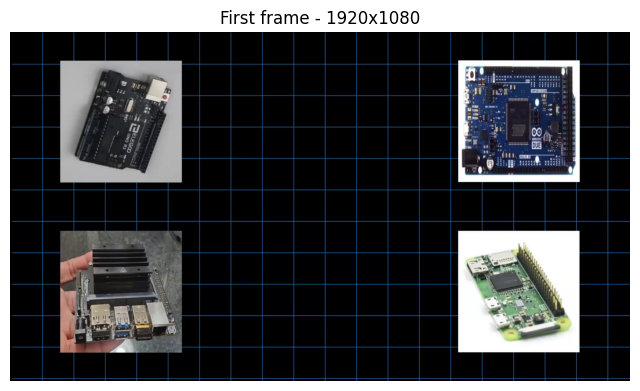

In [12]:
# show the first frame of the clip
cap = cv2.VideoCapture(CLIP_VIDEO)
ok, frame0 = cap.read()
cap.release()

frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(frame0_rgb)
plt.axis("off")
plt.title("First frame - " + str(W) + "x" + str(H))
plt.show()

In [13]:
# Test detection on the FIRST frame
cap = cv2.VideoCapture(CLIP_VIDEO)

ok, first_frame = cap.read()
cap.release()

if not ok:
    print("❌ Could not read first frame")

else:
    print("✅ First frame read successfully")

    # Raw detection with very low confidence
    first_det = model.predict(
        first_frame,
        imgsz=IMGSZ,
        conf=0.01,
        iou=IOU_NMS,
        device=device,
        verbose=False
    )[0]

    print("Number of detections:", len(first_det.boxes))

    for i, box in enumerate(first_det.boxes):
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        print(
            f"{i+1}. "
            f"Class = {names[cls_id]}, "
            f"Confidence = {conf:.3f}"
        )

✅ First frame read successfully
Number of detections: 10
1. Class = Arduino-Due, Confidence = 0.939
2. Class = Jetson Nano, Confidence = 0.930
3. Class = Raspberry-Pi-Zero-WH, Confidence = 0.928
4. Class = Arduino Uno Camera Shield, Confidence = 0.820
5. Class = Arduino Uno -Black-, Confidence = 0.534
6. Class = Wemos, Confidence = 0.045
7. Class = Wemos, Confidence = 0.029
8. Class = Wemos, Confidence = 0.023
9. Class = Wemos, Confidence = 0.013
10. Class = Wemos, Confidence = 0.012


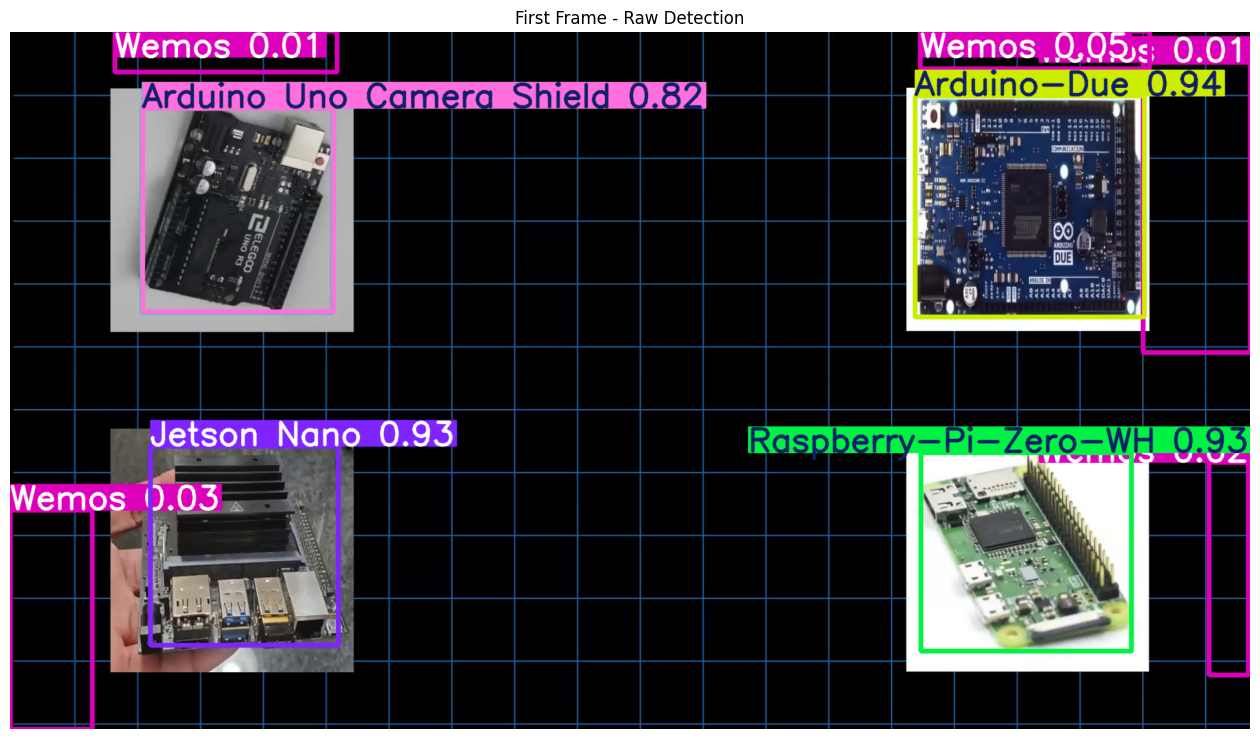

In [14]:
# Visualize FIRST FRAME detections

annotated_first = first_det.plot()

annotated_first = cv2.cvtColor(
    annotated_first,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 10))
plt.imshow(annotated_first)
plt.axis("off")
plt.title("First Frame - Raw Detection")
plt.show()

### Helpers

In [15]:
# ---------- drawing settings ----------
FULL_TRAIL = True
TRAIL_LEN = 60
KEEP_LOST_FRAMES = 200 #8
REPAIR_ID = True
MATCH_DIST = 250 #200

# occlusion zone
OCCLUSION_ZONE = None
# OCCLUSION_ZONE = (380, 100, 520, 420)

# BGR colors
PALETTE = [(0, 128, 255), (255, 200, 0), (200, 0, 255), (120, 255, 0),
           (0, 255, 255), (255, 100, 100), (255, 0, 150), (150, 255, 200)]


def get_color(track_id):
    return PALETTE[int(track_id) % len(PALETTE)]


def dim_color(color):
    return (int(color[0] * 0.55), int(color[1] * 0.55), int(color[2] * 0.55))


def draw_dashed_line(img, p1, p2, color, dash=7, thick=2):
    x1, y1 = p1
    x2, y2 = p2
    dist = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5
    if dist < 1:
        return
    steps = int(dist / dash)
    if steps < 1:
        steps = 1
    for k in range(0, steps, 2):
        a = k / float(steps)
        b = (k + 1) / float(steps)
        if b > 1.0:
            b = 1.0
        xa = int(x1 + (x2 - x1) * a)
        ya = int(y1 + (y2 - y1) * a)
        xb = int(x1 + (x2 - x1) * b)
        yb = int(y1 + (y2 - y1) * b)
        cv2.line(img, (xa, ya), (xb, yb), color, thick)


def draw_dashed_box(img, x1, y1, x2, y2, color, dash=10, thick=2):
    x1 = int(x1); y1 = int(y1); x2 = int(x2); y2 = int(y2)
    for x in range(x1, x2, dash * 2):
        x_end = min(x + dash, x2)
        cv2.line(img, (x, y1), (x_end, y1), color, thick)
        cv2.line(img, (x, y2), (x_end, y2), color, thick)
    for y in range(y1, y2, dash * 2):
        y_end = min(y + dash, y2)
        cv2.line(img, (x1, y), (x1, y_end), color, thick)
        cv2.line(img, (x2, y), (x2, y_end), color, thick)


def draw_label(img, x, y, text, color):
    x = int(x); y = int(y)
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), base = cv2.getTextSize(text, font, 0.5, 1)
    top = y - th - 8
    if top < 0:
        top = y + 2
    cv2.rectangle(img, (x, top), (x + tw + 8, top + th + 8), color, -1)
    cv2.putText(img, text, (x + 4, top + th + 2), font, 0.5, (0, 0, 0), 1, cv2.LINE_AA)


def draw_trail(img, points, color):
    solid = color
    faded = dim_color(color)
    for k in range(1, len(points)):
        x1, y1, pred1 = points[k - 1]
        x2, y2, pred2 = points[k]
        if pred1 or pred2:
            draw_dashed_line(img, (x1, y1), (x2, y2), faded, 7, 2)
        else:
            cv2.line(img, (x1, y1), (x2, y2), solid, 2)
    if len(points) > 0:
        cv2.circle(img, (points[-1][0], points[-1][1]), 4, solid, -1)


def draw_hud(img, frame_no, n_active, n_repair):
    h = img.shape[0]
    cv2.rectangle(img, (0, h - 70), (215, h), (0, 0, 0), -1)
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, "frame    : " + str(frame_no), (8, h - 48), font, 0.5, (255, 255, 255), 1)
    cv2.putText(img, "active   : " + str(n_active), (8, h - 28), font, 0.5, (255, 255, 255), 1)
    cv2.putText(img, "id fixed : " + str(n_repair), (8, h - 8), font, 0.5, (0, 200, 255), 1)


print("Drawing helpers ready")

Drawing helpers ready


### Tracking loop

In [16]:
from scipy.optimize import linear_sum_assignment

cap = cv2.VideoCapture(CLIP_VIDEO)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUT_VIDEO, fourcc, FPS_SRC, (W, H))

records = []
infer_times = []
frame_idx = 0

tracks = {}
next_id = 1
repair_log = []
seen_ids = []

FULL_RATIO = 0.95
MIN_GHOST_LEN = 15
ASSIGN_GATE = 150
CLASS_PENALTY = 120


def locked_cls(t):
    v = t["votes"]
    return max(v, key=v.get) if v else None


def predict_center(t, f):
    g = f - t["anchor_frame"]
    return t["anchor_cx"] + t["vx"] * g, t["anchor_cy"] + t["vy"] * g


def assign_cost(t, f, d):
    px, py = predict_center(t, f)
    fw, fh = t["full_w"], t["full_h"]
    dw, dh = d["x2"] - d["x1"], d["y2"] - d["y1"]
    ox = max(0.0, abs(d["cx"] - px) - max(0.0, (fw - dw) / 2))
    oy = max(0.0, abs(d["cy"] - py) - max(0.0, (fh - dh) / 2))
    cost = ox + oy
    lc = locked_cls(t)
    is_full = dw >= FULL_RATIO * fw and dh >= FULL_RATIO * fh
    if lc is not None and is_full and d["conf"] >= 0.5 and d["cls"] != lc and len(t["full_pts"]) >= MIN_GHOST_LEN:
        cost += CLASS_PENALTY
    return cost


start_all = time.time()

while True:
    ok, frame = cap.read()
    if not ok:
        break

    frame_idx = frame_idx + 1
    canvas = frame.copy()

    t0 = time.time()
    res = model.track(frame,
                      persist=True,
                      tracker=TRACKER_YAML,
                      conf=CONF,
                      iou=IOU_NMS,
                      imgsz=IMGSZ,
                      agnostic_nms=True,
                      augment=False,
                      device=device,
                      verbose=False)[0]
    infer_times.append(time.time() - t0)

    dets = []
    if res.boxes is not None and len(res.boxes) > 0:
        bxs = res.boxes.xyxy.cpu().numpy()
        confs = res.boxes.conf.cpu().numpy()
        clss = res.boxes.cls.cpu().numpy().astype(int)
        rids = res.boxes.id.cpu().numpy().astype(int) if res.boxes.id is not None else [-1] * len(bxs)
        for i in range(len(bxs)):
            x1, y1, x2, y2 = [float(v) for v in bxs[i]]
            dets.append({"x1": x1, "y1": y1, "x2": x2, "y2": y2,
                         "cx": (x1 + x2) / 2, "cy": (y1 + y2) / 2,
                         "conf": float(confs[i]), "cls": int(clss[i]), "raw": int(rids[i])})

    # ---- detection <-> track matching (Hungarian) ----
    live = [tid for tid, t in tracks.items() if frame_idx - t["last_frame"] <= KEEP_LOST_FRAMES]
    matches = {}
    if dets and live:
        C = np.full((len(dets), len(live)), 1e6)
        for i, d in enumerate(dets):
            for j, tid in enumerate(live):
                C[i, j] = assign_cost(tracks[tid], frame_idx, d)
        rows, cols = linear_sum_assignment(C)
        for i, j in zip(rows, cols):
            if C[i, j] <= ASSIGN_GATE:
                matches[i] = live[j]

    alive_ids = []
    boxes_to_draw = []

    for i, d in enumerate(dets):
        dw, dh = d["x2"] - d["x1"], d["y2"] - d["y1"]

        if i in matches:
            tid = matches[i]
            t = tracks[tid]
            if frame_idx - t["last_frame"] > 1 and t["was_lost"]:
                repair_log.append({"frame": frame_idx, "time_s": round(frame_idx / FPS_SRC, 2),
                                   "kept_id": tid, "gap_frames": frame_idx - t["last_frame"]})
        else:
            # notun board
            tid = next_id
            next_id += 1
            tracks[tid] = {"full_w": dw, "full_h": dh, "votes": {}, "full_pts": [],
                           "hist": [], "anchor_cx": d["cx"], "anchor_cy": d["cy"],
                           "anchor_frame": frame_idx, "vx": 0.0, "vy": 0.0,
                           "last_frame": frame_idx, "was_lost": False}
            t = tracks[tid]

        if tid not in seen_ids:
            seen_ids.append(tid)
        alive_ids.append(tid)

        t["full_w"] = max(t["full_w"], dw)
        t["full_h"] = max(t["full_h"], dh)
        is_full = dw >= FULL_RATIO * t["full_w"] and dh >= FULL_RATIO * t["full_h"]

        if is_full:
            t["votes"][d["cls"]] = t["votes"].get(d["cls"], 0.0) + d["conf"]
            t["full_pts"].append((frame_idx, d["cx"], d["cy"]))
            pts = t["full_pts"][-30:]
            if len(pts) >= 2 and pts[-1][0] != pts[0][0]:
                dfr = pts[-1][0] - pts[0][0]
                t["vx"] = (pts[-1][1] - pts[0][1]) / dfr
                t["vy"] = (pts[-1][2] - pts[0][2]) / dfr
            t["anchor_cx"], t["anchor_cy"], t["anchor_frame"] = d["cx"], d["cy"], frame_idx
        elif not t["votes"]:
            t["votes"][d["cls"]] = d["conf"]

        t["last_frame"] = frame_idx
        t["was_lost"] = False
        t["hist"].append((int(d["cx"]), int(d["cy"]), False))

        lc = locked_cls(t)
        name = names[lc]
        records.append({"frame": frame_idx, "track_id": tid, "x": d["x1"], "y": d["y1"],
                        "w": dw, "h": dh, "conf": d["conf"], "cls": lc, "cls_name": name,
                        "tracker_raw_id": d["raw"]})

        label = name + " " + str(int(d["conf"] * 100)) + "%  ID " + str(tid)
        boxes_to_draw.append((d["x1"], d["y1"], d["x2"], d["y2"], tid, label, False))

    for tid, t in tracks.items():
        if tid in alive_ids:
            continue
        gap = frame_idx - t["last_frame"]
        if gap <= 0 or gap > KEEP_LOST_FRAMES or len(t["full_pts"]) < MIN_GHOST_LEN:
            continue
        t["was_lost"] = True
        px, py = predict_center(t, frame_idx)
        gx1, gy1 = px - t["full_w"] / 2, py - t["full_h"] / 2
        gx2, gy2 = px + t["full_w"] / 2, py + t["full_h"] / 2
        if gx2 < 0 or gx1 > W or gy2 < 0 or gy1 > H:
            continue
        t["hist"].append((int(px), int(py), True))
        ghost_label = names[locked_cls(t)] + "  ID " + str(tid) + " - PREDICT ONLY"
        boxes_to_draw.append((gx1, gy1, gx2, gy2, tid, ghost_label, True))

    if OCCLUSION_ZONE is not None:
        zx1, zy1, zx2, zy2 = OCCLUSION_ZONE
        draw_dashed_box(canvas, zx1, zy1, zx2, zy2, (110, 110, 110), dash=14, thick=2)
        cv2.putText(canvas, "OCCLUSION ZONE", (int(zx1), int(zy2) + 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150, 150, 150), 1)

    for tid, t in tracks.items():
        if frame_idx - t["last_frame"] <= KEEP_LOST_FRAMES:
            pts = t["hist"]
            if not FULL_TRAIL and len(pts) > TRAIL_LEN:
                pts = pts[-TRAIL_LEN:]
            draw_trail(canvas, pts, get_color(tid))

    for x1, y1, x2, y2, tid, label, is_pred in boxes_to_draw:
        color = get_color(tid)
        if is_pred:
            draw_dashed_box(canvas, x1, y1, x2, y2, color)
        else:
            cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
        draw_label(canvas, x1, y1, label, color)

    draw_hud(canvas, frame_idx, len(alive_ids), len(repair_log))
    writer.write(canvas)

cap.release()
writer.release()
total_time = time.time() - start_all

df = pd.DataFrame(records)
df.to_csv(TRACKS_CSV, index=False)

print("Frames processed      :", frame_idx)
print("Detections with an ID :", len(df))
print("Unique track IDs      :", len(seen_ids))
print("IDs kept after occlusion :", len(repair_log))
for e in repair_log:
    print("  ", e)

Frames processed      : 600
Detections with an ID : 2217
Unique track IDs      : 4
IDs kept after occlusion : 12
   {'frame': 254, 'time_s': 8.47, 'kept_id': 2, 'gap_frames': 3}
   {'frame': 295, 'time_s': 9.83, 'kept_id': 1, 'gap_frames': 13}
   {'frame': 296, 'time_s': 9.87, 'kept_id': 4, 'gap_frames': 2}
   {'frame': 297, 'time_s': 9.9, 'kept_id': 1, 'gap_frames': 2}
   {'frame': 304, 'time_s': 10.13, 'kept_id': 4, 'gap_frames': 8}
   {'frame': 306, 'time_s': 10.2, 'kept_id': 1, 'gap_frames': 3}
   {'frame': 307, 'time_s': 10.23, 'kept_id': 4, 'gap_frames': 2}
   {'frame': 310, 'time_s': 10.33, 'kept_id': 1, 'gap_frames': 4}
   {'frame': 318, 'time_s': 10.6, 'kept_id': 4, 'gap_frames': 9}
   {'frame': 324, 'time_s': 10.8, 'kept_id': 1, 'gap_frames': 7}
   {'frame': 341, 'time_s': 11.37, 'kept_id': 4, 'gap_frames': 18}
   {'frame': 378, 'time_s': 12.6, 'kept_id': 2, 'gap_frames': 124}


### MOT file + FPS

In [17]:
# save the same tracks in MOT format (frame, id, x, y, w, h, conf, -1, -1, -1)
df_sorted = df.sort_values(["frame", "track_id"])

with open(TRACKS_MOT, "w") as f:
    for i, r in df_sorted.iterrows():
        line = "%d,%d,%.2f,%.2f,%.2f,%.2f,%.4f,-1,-1,-1\n" % (
            r["frame"], r["track_id"], r["x"], r["y"], r["w"], r["h"], r["conf"])
        f.write(line)

# speed numbers
mean_time = np.mean(infer_times)
INFER_FPS = 1.0 / mean_time
E2E_FPS = frame_idx / total_time

print("Mean inference time :", round(mean_time * 1000, 1), "ms/frame")
print("Inference FPS (T4)  :", round(INFER_FPS, 2))
print("End-to-end FPS (T4) :", round(E2E_FPS, 2))
print("MOT file saved      :", TRACKS_MOT)

Mean inference time : 88.7 ms/frame
Inference FPS (T4)  : 11.28
End-to-end FPS (T4) : 9.35
MOT file saved      : /kaggle/working/tracks_mot.txt


In [18]:
if not GT_AVAILABLE:
    unique_ids = df["track_id"].nunique()
    lengths = df.groupby("track_id")["frame"].agg(["min","max","count"])
    mean_len_frames = lengths["count"].mean()
    frag_per_track = {tid: int(np.sum(np.diff(np.sort(g["frame"].unique())) > 1))
                      for tid, g in df.groupby("track_id")}
    total_frag = int(sum(frag_per_track.values()))

    print("PROXY METRICS")
    print(f"  unique track IDs               : {unique_ids}")
    print(f"  expected object count (manual) : {EXPECTED_OBJECT_COUNT}")
    if EXPECTED_OBJECT_COUNT:
        print(f"  ID inflation ratio             : {unique_ids/EXPECTED_OBJECT_COUNT:.2f}x")
    print(f"  mean track length              : {mean_len_frames:.1f} frames ({mean_len_frames/FPS_SRC:.2f} s)")
    print(f"  median / longest track         : {lengths['count'].median():.1f} / {lengths['count'].max()} frames")
    print(f"  fragmentation count            : {total_frag}")
    print(f"  tracks with >=1 fragmentation  : {sum(v>0 for v in frag_per_track.values())}")
    print(f"  mean detection confidence      : {df['conf'].mean():.3f}")
    print(f"  inference FPS on T4            : {INFER_FPS:.2f}")
    print(f"  end-to-end FPS on T4           : {E2E_FPS:.2f}")
    display(lengths.sort_values("count", ascending=False).head(15))

PROXY METRICS
  unique track IDs               : 4
  expected object count (manual) : 10
  ID inflation ratio             : 0.40x
  mean track length              : 554.2 frames (18.48 s)
  median / longest track         : 571.0 / 600 frames
  fragmentation count            : 12
  tracks with >=1 fragmentation  : 3
  mean detection confidence      : 0.901
  inference FPS on T4            : 11.28
  end-to-end FPS on T4           : 9.35


,min,max,count
track_id,,,
3,1,600,600
1,1,600,576
4,1,600,566
2,1,600,475


### Video Play

In [19]:
# convert to h264 so the browser can play it, then show it
!ffmpeg -y -loglevel error -i "{OUT_VIDEO}" -c:v libx264 -preset fast -pix_fmt yuv420p "{OUT_VIDEO_H264}"

from IPython.display import Video, display

print("Annotated output video with persistent track IDs:")
display(Video(OUT_VIDEO_H264, embed=True, width=720))

Annotated output video with persistent track IDs:


### sample frame

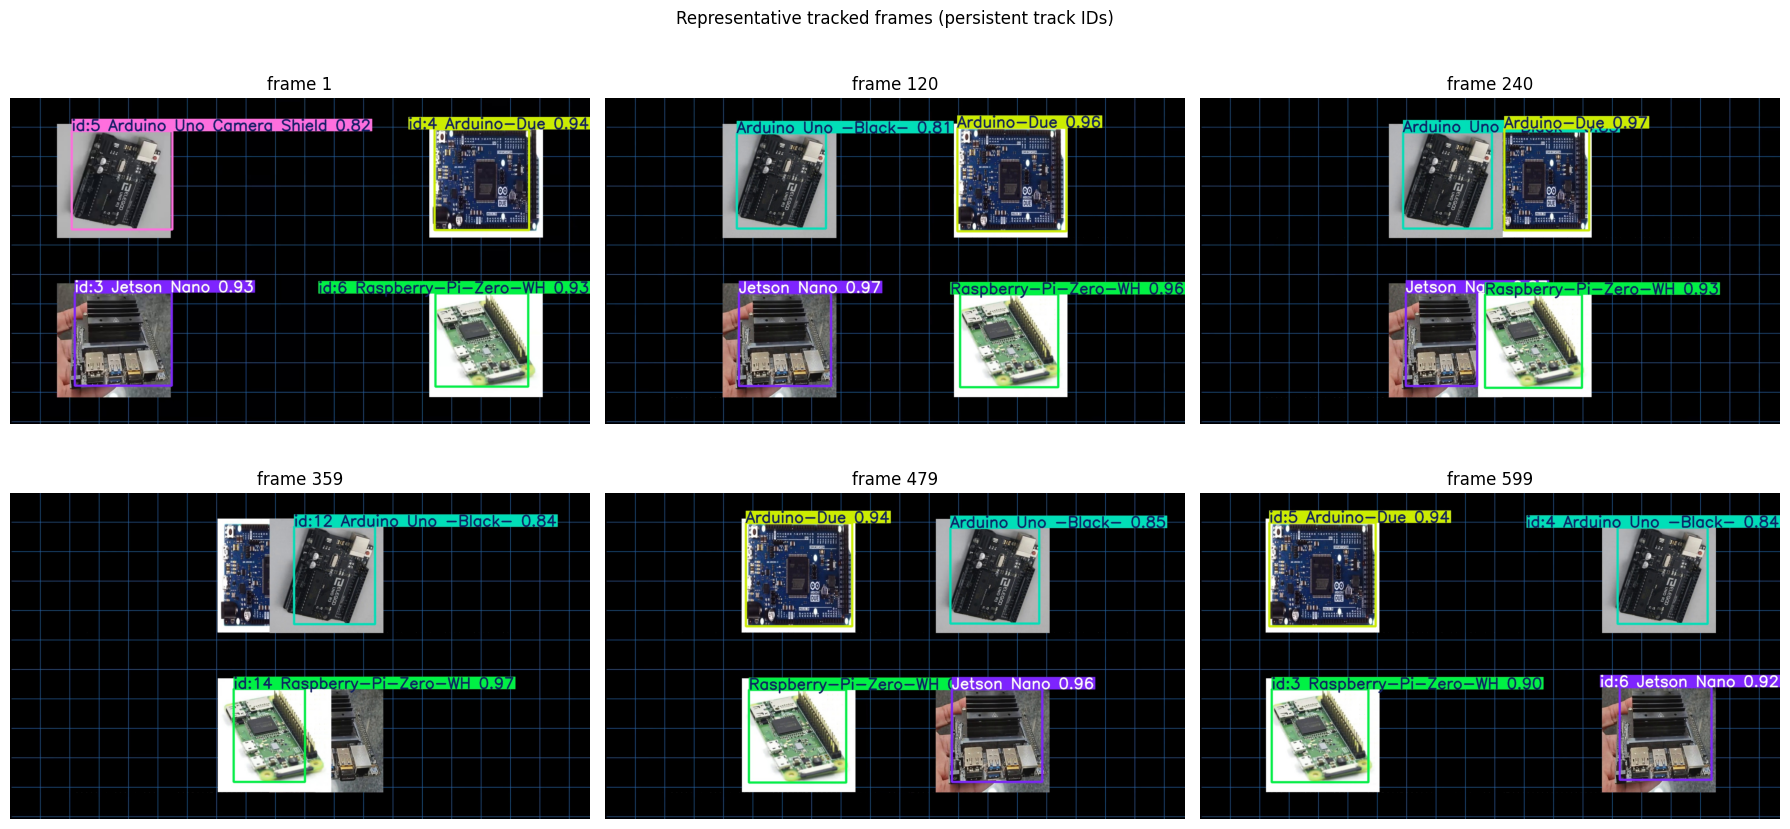

In [20]:
# pick 6 frames spread over the clip and save them as images
picks = np.linspace(1, N_FRAMES - 1, 6).astype(int).tolist()

cap = cv2.VideoCapture(CLIP_VIDEO)
saved_index = []
saved_path = []
idx = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    idx = idx + 1

    if idx in picks:
        res = model.track(frame,
                          persist=True,
                          tracker=TRACKER_YAML,
                          conf=CONF,
                          iou=IOU_NMS,
                          imgsz=IMGSZ,
                          augment=False,
                          device=device,
                          verbose=False)[0]

        p = FRAME_DIR + "/frame_" + str(idx) + ".jpg"
        cv2.imwrite(p, res.plot())
        saved_index.append(idx)
        saved_path.append(p)

cap.release()

# show them in a 2 x 3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for i in range(len(axes)):
    axes[i].axis("off")
    if i < len(saved_path):
        img = cv2.imread(saved_path[i])
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title("frame " + str(saved_index[i]))

plt.suptitle("Representative tracked frames (persistent track IDs)")
plt.tight_layout()
plt.show()

## GT metrics

In [21]:
# this part only runs if we have ground truth (we do not, so it is skipped)
if GT_AVAILABLE:
    import motmetrics as mm

    gt = pd.read_csv(GT_PATH, header=None,
                     names=["frame", "id", "x", "y", "w", "h", "conf", "cls", "vis"])
    gt = gt[gt["conf"] > 0]

    pr = pd.read_csv(TRACKS_MOT, header=None,
                     names=["frame", "id", "x", "y", "w", "h", "conf", "a", "b", "c"])

    acc = mm.MOTAccumulator(auto_id=False)

    all_frames = sorted(set(gt["frame"]).union(set(pr["frame"])))
    for fr in all_frames:
        g = gt[gt["frame"] == fr]
        p = pr[pr["frame"] == fr]
        d = mm.distances.iou_matrix(g[["x", "y", "w", "h"]].values,
                                    p[["x", "y", "w", "h"]].values,
                                    max_iou=1 - GT_IOU_THRESH)
        acc.update(g["id"].astype(int).tolist(),
                   p["id"].astype(int).tolist(),
                   d, frameid=int(fr))

    metric_list = ["num_frames", "num_unique_objects", "mota", "motp", "idf1",
                   "num_switches", "mostly_tracked", "partially_tracked",
                   "mostly_lost", "num_fragmentations", "num_false_positives",
                   "num_misses", "precision", "recall"]

    mh = mm.metrics.create()
    summary = mh.compute(acc, name="tracker", metrics=metric_list)

    n_obj = summary.loc["tracker", "num_unique_objects"]
    summary["MT_ratio"] = summary["mostly_tracked"] / n_obj
    summary["ML_ratio"] = summary["mostly_lost"] / n_obj
    summary["MOTP_iou"] = 1 - summary["motp"]

    print(mm.io.render_summary(summary,
                               formatters=mh.formatters,
                               namemap=mm.io.motchallenge_metric_names))
    summary.to_csv(working_dir + "mot_metrics.csv")
else:
    print("GT_AVAILABLE = False -> proxy metrics below.")

GT_AVAILABLE = False -> proxy metrics below.


## Proxy metrics

In [22]:
# proxy metrics (no ground truth needed)
if not GT_AVAILABLE:
    unique_ids = df["track_id"].nunique()
    lengths = df.groupby("track_id")["frame"].agg(["min", "max", "count"])
    mean_len_frames = lengths["count"].mean()

    # fragmentation = a track disappears and comes back later
    total_frag = 0
    tracks_with_frag = 0

    for tid, g in df.groupby("track_id"):
        frames = np.sort(g["frame"].unique())
        gaps = np.diff(frames)
        n_gap = int(np.sum(gaps > 1))
        total_frag = total_frag + n_gap
        if n_gap > 0:
            tracks_with_frag = tracks_with_frag + 1

    print("PROXY METRICS")
    print("  unique track IDs              :", unique_ids)
    print("  expected object count (manual):", EXPECTED_OBJECT_COUNT)
    if EXPECTED_OBJECT_COUNT:
        print("  ID inflation ratio            :", round(unique_ids / EXPECTED_OBJECT_COUNT, 2), "x")
    print("  mean track length             :", round(mean_len_frames, 1), "frames (",
          round(mean_len_frames / FPS_SRC, 2), "s )")
    print("  median track length           :", lengths["count"].median())
    print("  longest track                 :", lengths["count"].max())
    print("  fragmentation count           :", total_frag)
    print("  tracks with fragmentation     :", tracks_with_frag)
    print("  mean detection confidence     :", round(df["conf"].mean(), 3))
    print("  inference FPS on T4           :", round(INFER_FPS, 2))
    print("  end-to-end FPS on T4          :", round(E2E_FPS, 2))

    display(lengths.sort_values("count", ascending=False).head(15))

PROXY METRICS
  unique track IDs              : 4
  expected object count (manual): 10
  ID inflation ratio            : 0.4 x
  mean track length             : 554.2 frames ( 18.48 s )
  median track length           : 571.0
  longest track                 : 600
  fragmentation count           : 12
  tracks with fragmentation     : 3
  mean detection confidence     : 0.901
  inference FPS on T4           : 11.28
  end-to-end FPS on T4          : 9.35


,min,max,count
track_id,,,
3,1,600,600
1,1,600,576
4,1,600,566
2,1,600,475


## Graph

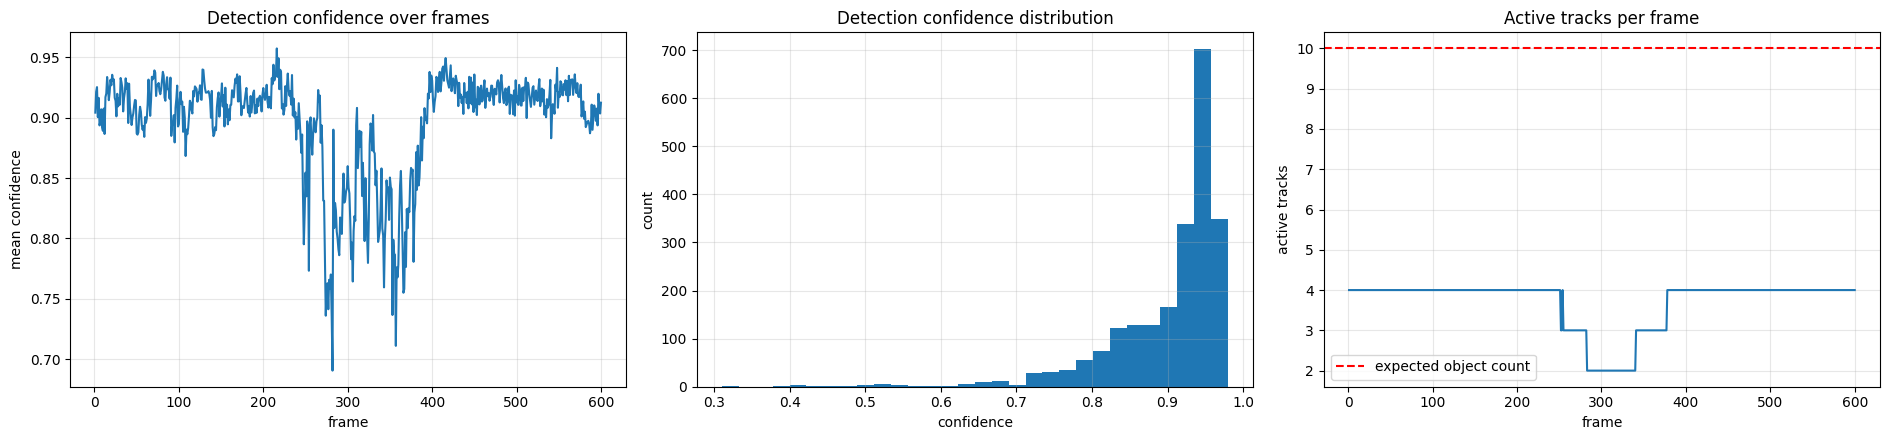

In [23]:
if not GT_AVAILABLE:
    per_frame = df.groupby("frame")["conf"].agg(["mean", "count"])

    fig, ax = plt.subplots(1, 3, figsize=(19, 4.5))

    ax[0].plot(per_frame.index, per_frame["mean"])
    ax[0].set_xlabel("frame")
    ax[0].set_ylabel("mean confidence")
    ax[0].set_title("Detection confidence over frames")
    ax[0].grid(alpha=0.3)

    ax[1].hist(df["conf"], bins=30)
    ax[1].set_xlabel("confidence")
    ax[1].set_ylabel("count")
    ax[1].set_title("Detection confidence distribution")
    ax[1].grid(alpha=0.3)

    ax[2].plot(per_frame.index, per_frame["count"])
    if EXPECTED_OBJECT_COUNT:
        ax[2].axhline(EXPECTED_OBJECT_COUNT, ls="--", c="r", label="expected object count")
        ax[2].legend()
    ax[2].set_xlabel("frame")
    ax[2].set_ylabel("active tracks")
    ax[2].set_title("Active tracks per frame")
    ax[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Manual ID switch + save

In [24]:
# write down the ID switches you saw yourself in the video above
if not GT_AVAILABLE:
    MANUAL_ID_SWITCHES = [
        # {"approx_time_s": 4.2, "old_id": 3, "new_id": 11, "cause": "occlusion"},
    ]

    print("ID-switch events observed by manual inspection:", len(MANUAL_ID_SWITCHES))
    print("IDs repaired after occlusion                 :", len(repair_log))
    for e in MANUAL_ID_SWITCHES:
        print("  ", e)

    proxy = {}
    proxy["unique_track_ids"] = int(unique_ids)
    proxy["expected_object_count"] = EXPECTED_OBJECT_COUNT
    proxy["manual_id_switches"] = len(MANUAL_ID_SWITCHES)
    proxy["ids_repaired_after_occlusion"] = len(repair_log)
    proxy["mean_track_length_frames"] = float(mean_len_frames)
    proxy["mean_track_length_sec"] = float(mean_len_frames / FPS_SRC)
    proxy["fragmentation_count"] = total_frag
    proxy["mean_detection_confidence"] = float(df["conf"].mean())
    proxy["inference_fps_t4"] = float(INFER_FPS)
    proxy["end_to_end_fps_t4"] = float(E2E_FPS)

    with open(working_dir + "proxy_metrics.json", "w") as f:
        json.dump(proxy, f, indent=2)

    display(pd.DataFrame([proxy]).T.rename(columns={0: "value"}))

ID-switch events observed by manual inspection: 0
IDs repaired after occlusion                 : 12


,value
unique_track_ids,4.000000
expected_object_count,10.000000
manual_id_switches,0.000000
ids_repaired_after_occlusion,12.000000
mean_track_length_frames,554.250000
mean_track_length_sec,18.475000
fragmentation_count,12.000000
mean_detection_confidence,0.901019
inference_fps_t4,11.277145
end_to_end_fps_t4,9.349814


## File list

In [25]:
# list every file we made
for root, dirs, files in os.walk(working_dir):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        size_mb = os.path.getsize(p) / 1e6
        print(round(size_mb, 2), "MB  ", p)

0.0 MB   /kaggle/working/bytetrack_partB.yaml
3.1 MB   /kaggle/working/clip_trimmed.mp4
0.0 MB   /kaggle/working/data.yaml
28.98 MB   /kaggle/working/group-k_partB_tracked.mp4
5.86 MB   /kaggle/working/group-k_partB_tracked_h264.mp4
0.0 MB   /kaggle/working/proxy_metrics.json
26.5 MB   /kaggle/working/source_raw.mp4
0.0 MB   /kaggle/working/ssl_ranking_rho20.csv
0.26 MB   /kaggle/working/tracks.csv
0.11 MB   /kaggle/working/tracks_mot.txt
0.0 MB   /kaggle/working/video_doc.json
0.0 MB   /kaggle/working/best_ssl_detector/best_ssl_meta.json
18.98 MB   /kaggle/working/best_ssl_detector/dinov3_yolo12s_rho20_best.pt
0.6 MB   /kaggle/working/simclr_test_eval/BoxF1_curve.png
0.12 MB   /kaggle/working/simclr_test_eval/BoxPR_curve.png
0.51 MB   /kaggle/working/simclr_test_eval/BoxP_curve.png
0.42 MB   /kaggle/working/simclr_test_eval/BoxR_curve.png
0.54 MB   /kaggle/working/simclr_test_eval/confusion_matrix.png
0.54 MB   /kaggle/working/simclr_test_eval/confusion_matrix_normalized.png
0.58 MB  

In [26]:
# ekta random frame-e raw detection confidences dekho (tracking chara, shudhu predict)
cap = cv2.VideoCapture(CLIP_VIDEO)
cap.set(cv2.CAP_PROP_POS_FRAMES, 400)
ok, frame = cap.read()
cap.release()

res = model.predict(frame, imgsz=IMGSZ, conf=0.01, iou=IOU_NMS, device=device, verbose=False)[0]
print("Total raw detections (conf>=0.01):", len(res.boxes))
for b in res.boxes:
    print(f"  {names[int(b.cls)]}: {float(b.conf):.3f}")

Total raw detections (conf>=0.01): 7
  Raspberry-Pi-Zero-WH: 0.950
  Arduino-Due: 0.937
  Jetson Nano: 0.936
  Arduino Uno -Black-: 0.833
  Arduino Uno Camera Shield: 0.191
  Jetson Nano: 0.050
  Wemos: 0.024
